<a href="https://colab.research.google.com/github/Roua-Elayeb/Conception-de-Robots-Intelligents-avec-NVIDIA-Jetson/blob/main/Reseaux%20%20Convolutionnels%20(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


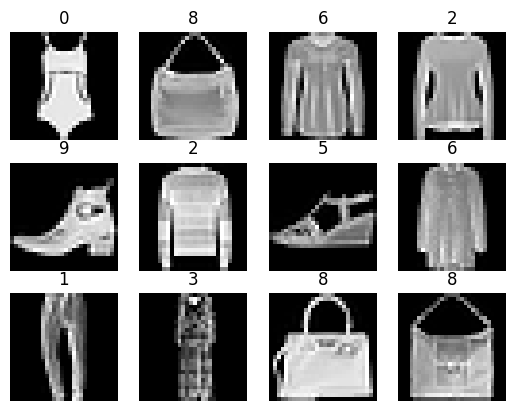

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# Charger dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalisation
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape (28,28,1)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Création validation (10%)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1)

# Visualisation
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(patience=3)
checkpoint = tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=2,
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)

# Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

Epoch 1/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.7811 - loss: 0.6013

844/844 ━━━━━━━━━━━━━━━━━━━━ 102s 119ms/step - accuracy: 0.8459 - loss: 0.4261 - val_accuracy: 0.8908 - val_loss: 0.3004
Epoch 2/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8937 - loss: 0.2846

844/844 ━━━━━━━━━━━━━━━━━━━━ 99s 117ms/step - accuracy: 0.8986 - loss: 0.2724 - val_accuracy: 0.9110 - val_loss: 0.2490
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9019 - loss: 0.2668
Test accuracy: 0.9018999934196472


In [ ]:
def create_model(padding='same', stride=1):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding=padding, strides=stride, input_shape=(28,28,1)),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu', padding=padding, strides=stride),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'), # Changed padding to 'same' here

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
model_A = create_model('same', 1)
model_A.fit(x_train, y_train, validation_data=(x_val,y_val), epochs=1)

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 166s 97ms/step - accuracy: 0.8576 - loss: 0.3911 - val_accuracy: 0.8905 - val_loss: 0.2978


In [ ]:
model_B = create_model('valid', 1)
model_B.fit(x_train, y_train, validation_data=(x_val,y_val), epochs=1)

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 36ms/step - accuracy: 0.8201 - loss: 0.4908 - val_accuracy: 0.8732 - val_loss: 0.3315


In [ ]:
model_C = create_model('same', 2)
model_C.fit(x_train, y_train, validation_data=(x_val,y_val), epochs=2)

Epoch 1/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8074 - loss: 0.5262 - val_accuracy: 0.8713 - val_loss: 0.3605
Epoch 2/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.8792 - loss: 0.3293 - val_accuracy: 0.8918 - val_loss: 0.2969


In [ ]:
model_D = create_model('valid', 2)
model_D.fit(x_train, y_train, validation_data=(x_val,y_val), epochs=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7475 - loss: 0.6866 - val_accuracy: 0.8122 - val_loss: 0.5112
Epoch 2/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8322 - loss: 0.4539 - val_accuracy: 0.8368 - val_loss: 0.4529


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


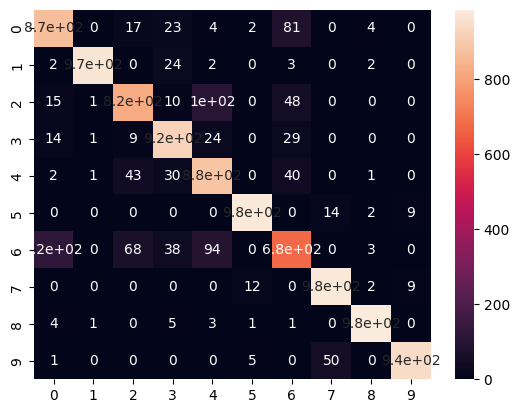

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1000
           1       1.00      0.97      0.98      1000
           2       0.86      0.82      0.84      1000
           3       0.88      0.92      0.90      1000
           4       0.79      0.88      0.83      1000
           5       0.98      0.97      0.98      1000
           6       0.77      0.68      0.72      1000
           7       0.94      0.98      0.96      1000
           8       0.99      0.98      0.99      1000
           9       0.98      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matrice confusion
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True)
plt.show()

# Rapport
print(classification_report(y_test, y_pred_classes))

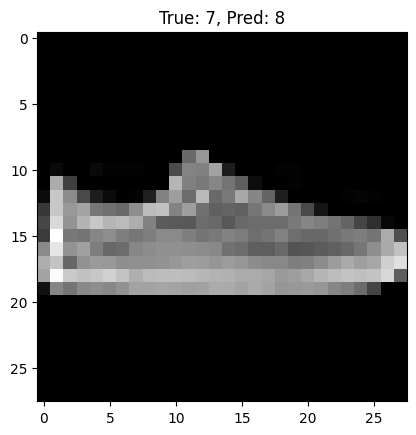

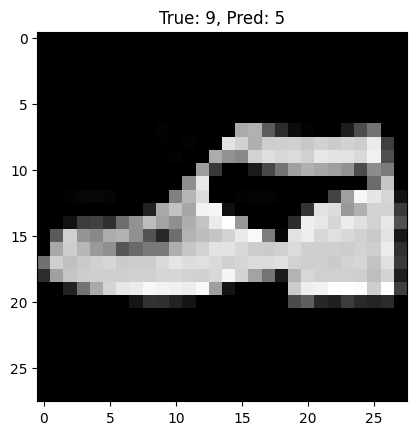

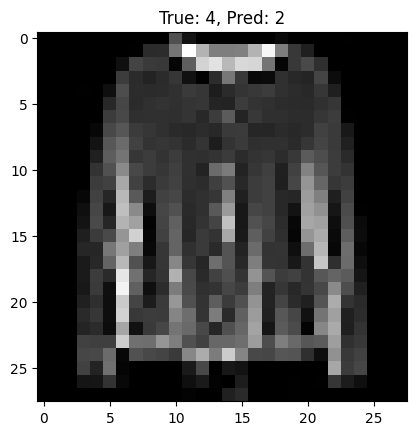

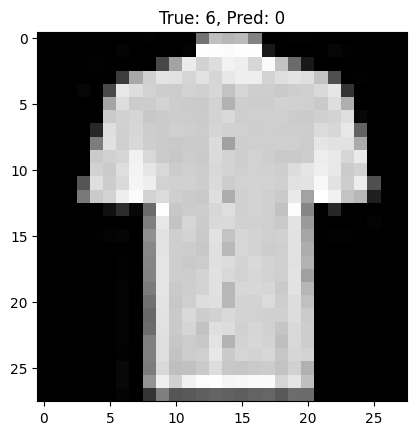

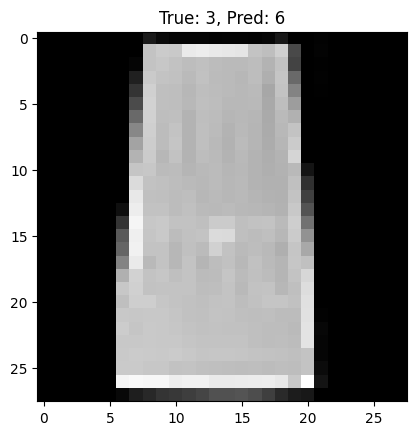

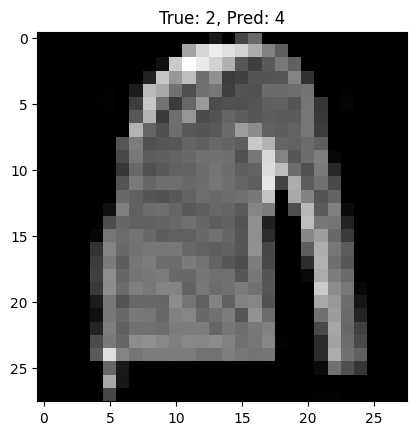

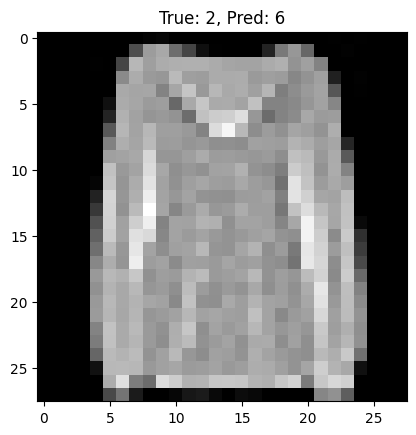

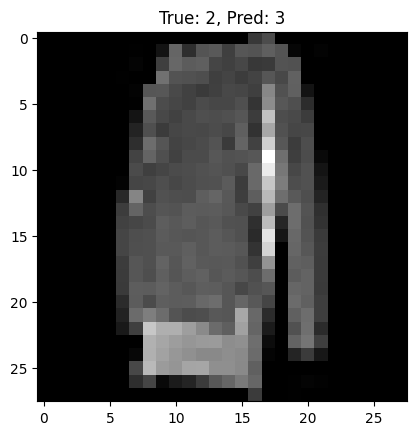

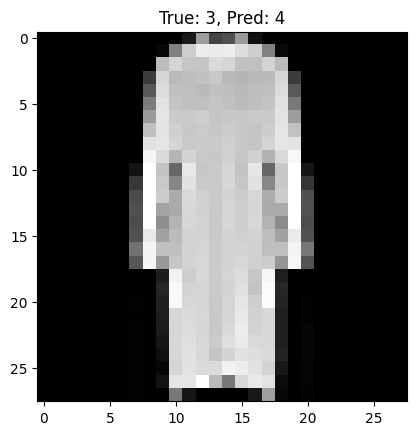

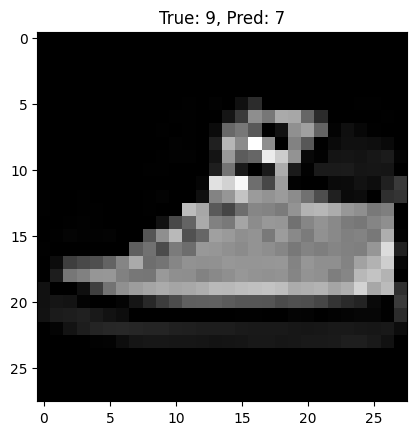

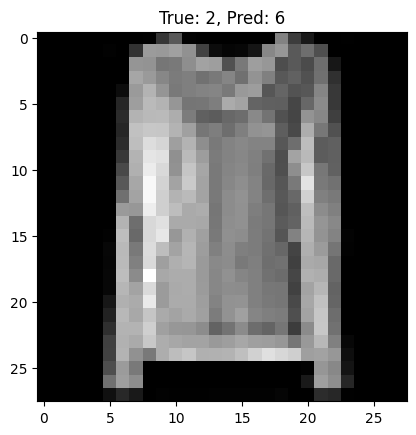

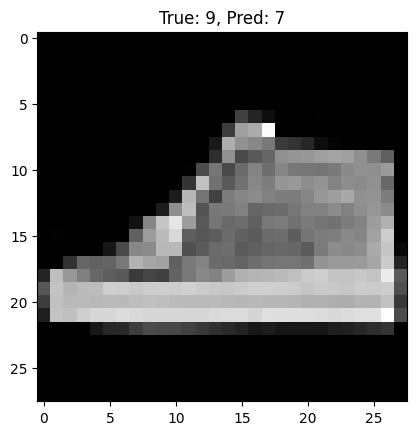

In [ ]:
errors = np.where(y_pred_classes != y_test)[0]

for i in range(12):
    idx = errors[i]
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred_classes[idx]}")
    plt.show()

In [ ]:
import tensorflow_datasets as tfds

dataset, info = tfds.load('tf_flowers', with_info=True, as_supervised=True)

# Split
train_data = dataset['train'].take(80)
val_data = dataset['train'].skip(80).take(10)
test_data = dataset['train'].skip(90)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.TD3AAZ_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [ ]:
IMG_SIZE = 180

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess).batch(32)
val_data = val_data.map(preprocess).batch(32)
test_data = test_data.map(preprocess).batch(32)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(180,180,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_data, validation_data=val_data, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.1250 - loss: 8.1867 - val_accuracy: 0.2000 - val_loss: 3.2803
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.3125 - loss: 2.2030 - val_accuracy: 0.2000 - val_loss: 1.6769
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.2375 - loss: 1.6076 - val_accuracy: 0.2000 - val_loss: 1.6020
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5250 - loss: 1.4108 - val_accuracy: 0.2000 - val_loss: 1.4996
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6250 - loss: 1.2111 - val_accuracy: 0.3000 - val_loss: 1.4069
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6625 - loss: 1.0088 - val_accuracy: 0.2000 - val_loss: 1.4885
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7625 - loss: 0.7520 - val_accuracy: 0.5000 - val_loss: 1.3130
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8750 - loss: 0.4664 - val_accuracy: 0.4000 - val_loss: 1.7697
Epoch 9/1

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(5, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Ce mini-projet consiste à préparer des données d’images, entraîner un modèle CNN de base, puis analyser l’impact du **stride** et du **padding** sur ses performances. Ensuite, un modèle plus avancé est construit et optimisé (dropout, augmentation…) afin d’améliorer les résultats. Enfin, les performances sont évaluées et les erreurs sont analysées.
